In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import pickle as pkl
import networkx as nx
import matplotlib.pyplot as plt
import pyomo.environ as pe


In [3]:

import visualizations as vis

import good
from good.reload import deep_reload

This nodebook shows an example of how to run GOOD for a pre-built graph. In this case the aggregated California example graph is loaded and run for 7 days with results plotted. The same is done with flexible base loads in the second example.

The first step is to load the graph. Let's use the WECC example.

In [4]:
deep_reload(good)
graph = good.graph.graph_from_json('Examples/WEC.json')

graph.nodes

NodeView(('WECC_AZ', 'WECC_CO', 'WECC_ID', 'WECC_IID', 'WECC_MT', 'WECC_NM', 'WECC_NNV', 'WECC_PNW', 'WECC_SCE', 'WECC_SNV', 'WECC_UT', 'WECC_WY', 'WEC_BANC', 'WEC_CALN', 'WEC_LADW', 'WEC_SDGE'))

First we will run the grid with custom policies

In [5]:
'''
Loading graph and policies
'''
deep_reload(good)

graph = good.graph.graph_from_json('Examples/WEC.json')

policies = good.utilities.read_json('Examples/policies.json')

In [6]:
'''
Building from graph for 7 day run - 06/01:00:00:00 - 06/07:23:59:59
'''
deep_reload(good)

kw = {
    'verbose': True,
    'steps': (6 * 32 * 24, 6 * 32 * 24 + 24 * 7),
    'amortization_period': 31536000,
    'shortfall_capacity': np.inf,
    'shortfall_cost': 1e3,
    'wastage_capacity': np.inf,
    'wastage_cost': 1e3,
}

network = good.optimization.network.Network(**kw).from_graph(
    graph, policies)

'''
Building the model
'''

network.build()

'''
Printing model size report
'''

network.size()

Parameters Built: 2.22491455078125
Variables Built: 2.230625629425049
Constraints Built: 13.57487416267395
Objective Built: 1.036712646484375


ModelSizeReport(activated = Bunch(binary_variables = 0, constraints = 1739584, continuous_variables = 621755, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 621755), overall = Bunch(binary_variables = 0, constraints = 1739584, continuous_variables = 621755, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 621755), warning = Bunch(unassociated_disjuncts = 0))

In [7]:
'''
Solving the model
'''
deep_reload(good)

kw = {
    'solver': {
        '_name': 'cbc',
    },
}

network.solve(**kw)
solution = network.solution

print(f'Objective Value: {pe.value(network.model.objective)}')

Problem Solved: 256.25851011276245
Objective Value: 43921855.00387115


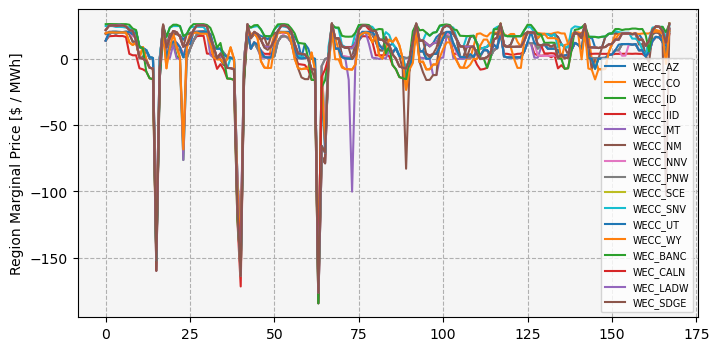

In [8]:
'''
Plotting LMPs
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 4))

_ = vis.plot_lmps(ax, solution)

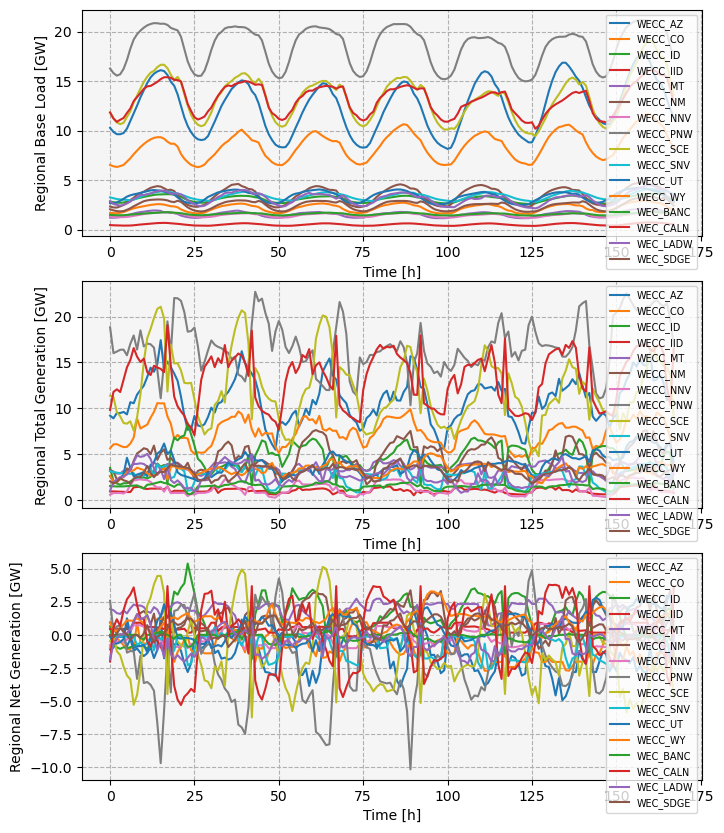

In [9]:
'''
Plotting Regional loads and generation
'''
deep_reload(vis)

fig, ax = plt.subplots(3, 1, figsize = (8, 10))

_ = vis.plot_base_loads(ax[0], solution)
_ = vis.plot_total_generation(ax[1], solution)
_ = vis.plot_net_generation(ax[2], solution)

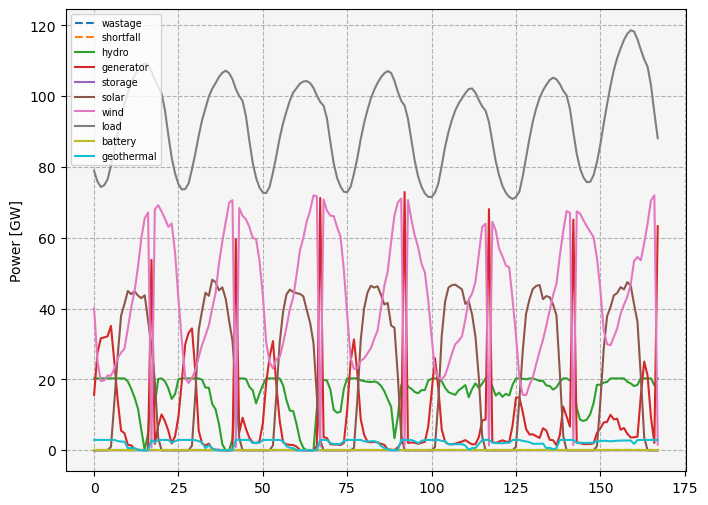

In [10]:
'''
Plotting generation by type
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 6))

_ = vis.plot_generation_by_type(ax, solution)

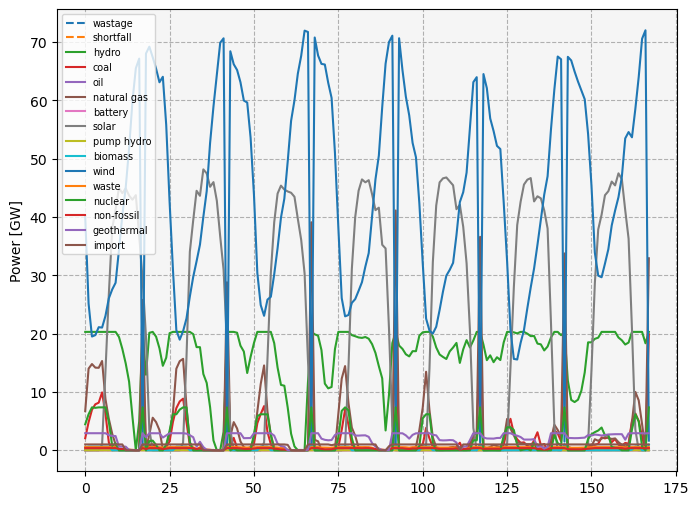

In [11]:
'''
Plotting generation by fuel
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 6))

_ = vis.plot_generation_by_fuel(ax, solution)

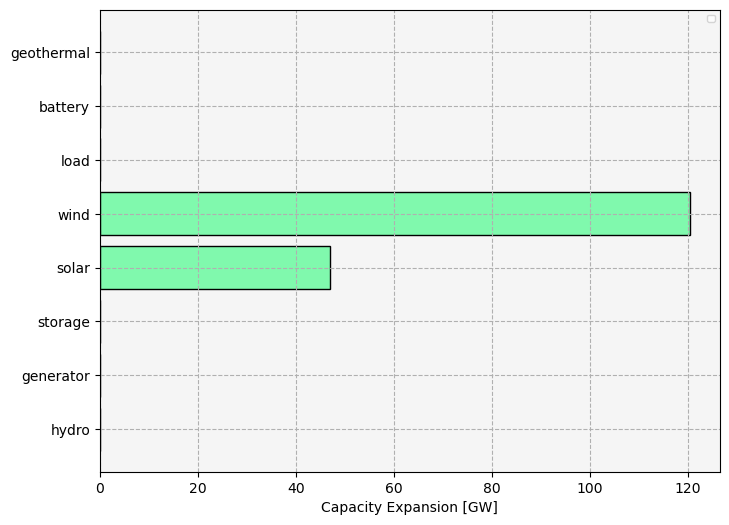

In [12]:
'''
Plotting capex by fuel
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 6))

_ = vis.plot_capex_by_type(ax, solution)

Now, let's implement custom policies

In [13]:
'''
Loading graph and policies - with no capex
'''
deep_reload(good)

graph = good.graph.graph_from_json('Examples/WEC.json')

# for source, node in graph._node.items():
#     for handle, asset in node['assets'].items():

#         if asset['_class'] == 'Store':

#             asset['capex_cost'] = 0
#             print('a')

policies = {
    'california_ps':{
        '_class': 'Portfolio_Standard',
        'ratio': 0.85,
        'inclusion_criteria': {
            0: "lambda a: a.get('renewable', False)",
            1: "lambda a: a.get('_class', '') != 'Store'",
            2: "lambda a: a.get('type', '') != 'load'",
            3: "lambda a: a.get('jurisdiction', '') == 'CA'"
        },
        'exclusion_criteria': {
            0: "lambda a: not a.get('renewable', False)",
            1: "lambda a: a.get('_class', '') != 'Store'",
            2: "lambda a: a.get('type', '') != 'load'",
            3: "lambda a: a.get('jurisdiction', '') == 'CA'"
        },
    },
    'california_ct': {
        '_class': 'Capacity_Target',
        'target': 70e9,
        'inclusion_criteria': {
            0: "lambda a: a.get('renewable', False)",
            1: "lambda a: a.get('_class', '') != 'Store'",
            2: "lambda a: a.get('type', '') != 'load'",
            3: "lambda a: a.get('jurisdiction', '') == 'CA'"
        },
    },
    'california_rm' : {
        '_class': 'Reserve_Margin',
        'margin': .1,
        'sign': -1,
        'demand_criteria': {
            2: "lambda a: a.get('type', '') == 'load'",
        },
        'supply_criteria': {
            1: "lambda a: a.get('_class', '') != 'Store'",
            2: "lambda a: a.get('type', '') != 'load'",
        },
    },
}

In [14]:
'''
Building from graph for 7 day run - 06/01:00:00:00 - 06/07:23:59:59
'''
deep_reload(good)

kw = {
    'verbose': True,
    'steps': (6 * 32 * 24, 6 * 32 * 24 + 24 * 7),
    'amortization_period': 31536000,
    'shortfall_capacity': np.inf,
    'shortfall_cost': 1e3,
    'wastage_capacity': np.inf,
    'wastage_cost': 1e3,
}

network = good.optimization.network.Network(**kw).from_graph(
    graph, policies)

'''
Building the model
'''

network.build()

'''
Printing model size report
'''

network.size()

Parameters Built: 2.0801124572753906
Variables Built: 3.7117855548858643
Constraints Built: 13.568878650665283
Objective Built: 1.045701265335083


ModelSizeReport(activated = Bunch(binary_variables = 0, constraints = 1739722, continuous_variables = 621726, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 621726), overall = Bunch(binary_variables = 0, constraints = 1739722, continuous_variables = 621726, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 621726), warning = Bunch(unassociated_disjuncts = 0))

In [15]:
'''
Solving the model
'''
deep_reload(good)

kw = {
    'solver': {
        '_name': 'cbc',
    },
}

network.solve(**kw)
solution = network.solution

print(f'Objective Value: {pe.value(network.model.objective)}')

Problem Solved: 579.4441244602203
Objective Value: 46362795.080267325


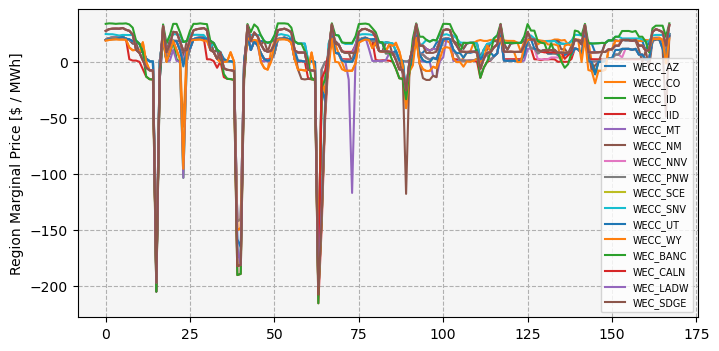

In [16]:
'''
Plotting LMPs
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 4))

_ = vis.plot_lmps(ax, solution)

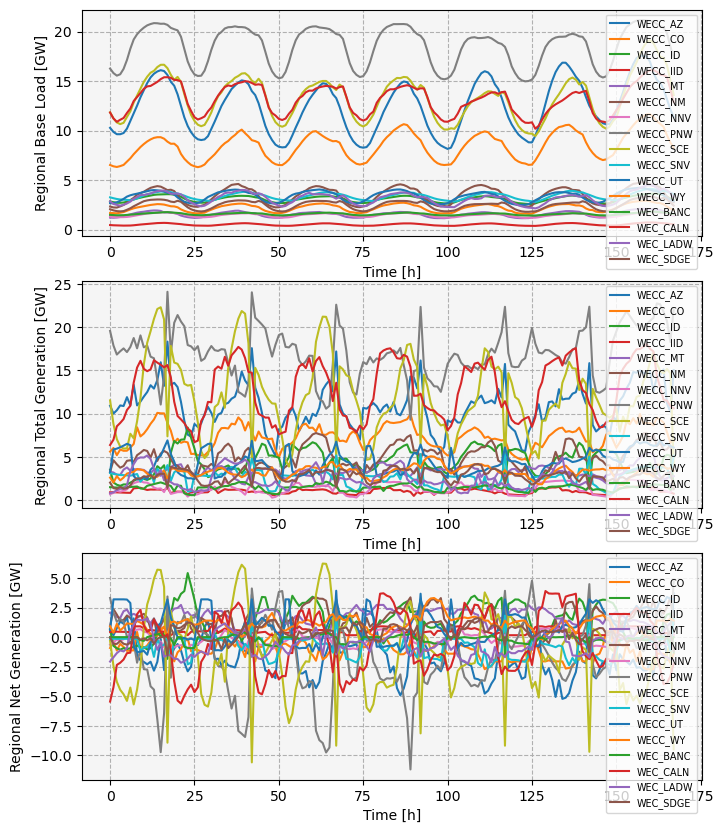

In [17]:
'''
Plotting Regional loads and generation
'''
deep_reload(vis)

fig, ax = plt.subplots(3, 1, figsize = (8, 10))

_ = vis.plot_base_loads(ax[0], solution)
_ = vis.plot_total_generation(ax[1], solution)
_ = vis.plot_net_generation(ax[2], solution)

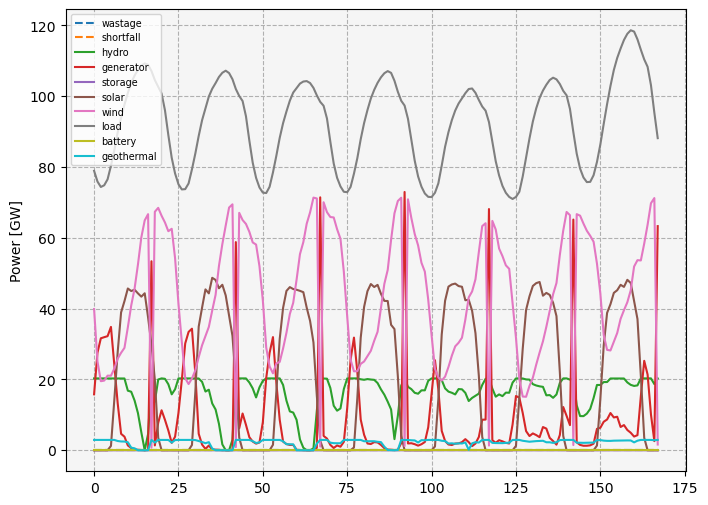

In [18]:
'''
Plotting generation by type
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 6))

_ = vis.plot_generation_by_type(ax, solution)

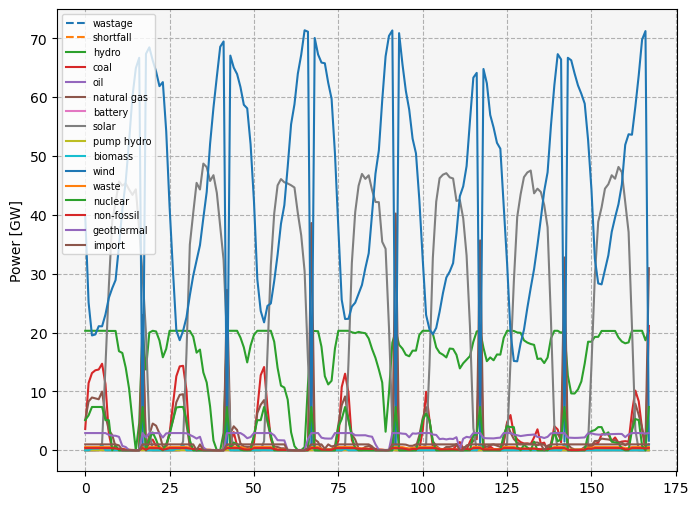

In [19]:
'''
Plotting generation by fuel
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 6))

_ = vis.plot_generation_by_fuel(ax, solution)

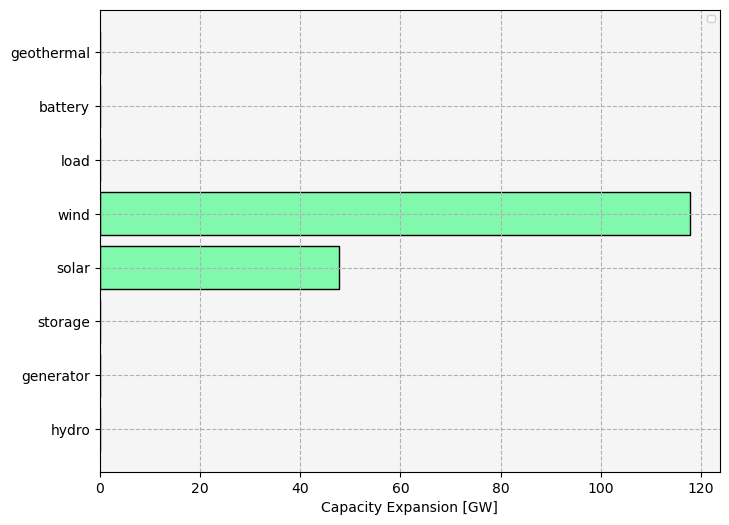

In [20]:
'''
Plotting capex by fuel
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 6))

_ = vis.plot_capex_by_type(ax, solution)